In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch 5 years of historical data for Apple Inc.
aapl = yf.Ticker("AAPL")
df = aapl.history(period="5y")

# Reset index to bring Date into a regular column
df.reset_index(inplace=True)

# Display basic information and the first 5 rows
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1255 entries, 0 to 1254
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype                          
---  ------        --------------  -----                          
 0   Date          1255 non-null   datetime64[s, America/New_York]
 1   Open          1254 non-null   float64                        
 2   High          1254 non-null   float64                        
 3   Low           1254 non-null   float64                        
 4   Close         1254 non-null   float64                        
 5   Volume        1255 non-null   int64                          
 6   Dividends     1255 non-null   float64                        
 7   Stock Splits  1255 non-null   float64                        
dtypes: datetime64[s, America/New_York](1), float64(6), int64(1)
memory usage: 78.6 KB
None


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2021-07-26 00:00:00-04:00,144.526449,146.047059,143.970833,145.228271,72434100,0.0,0.0
1,2021-07-27 00:00:00-04:00,145.355004,145.442743,141.875148,143.064346,104818600,0.0,0.0
2,2021-07-28 00:00:00-04:00,141.153828,143.259296,138.941137,141.319534,118931200,0.0,0.0
3,2021-07-29 00:00:00-04:00,141.036849,142.849888,140.929626,141.962860,56699500,0.0,0.0
4,2021-07-30 00:00:00-04:00,140.734694,142.635457,140.471506,142.177322,70440600,0.0,0.0


In [2]:
df['Price_Range'] = df['High'] - df['Low']

In [3]:
# 1. Moving Averages (7-day and 30-day)
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

# 2. Daily Price Change & Percentage Change
df['Price_Change'] = df['Close'].diff()
df['Daily_Return'] = df['Close'].pct_change() * 100

# 3. Rolling Volatility (30-day standard deviation of returns)
df['Volatility_30d'] = df['Daily_Return'].rolling(window=30).std()

# Display the tail to verify the new columns
df[['Date', 'Close', 'MA_7', 'MA_30', 'Daily_Return', 'Price_Range']].tail()

,Date,Close,MA_7,MA_30,Daily_Return,Price_Range
1250,2026-07-20 00:00:00-04:00,326.589996,324.082855,303.544333,-2.142385,10.029999
1251,2026-07-21 00:00:00-04:00,327.739990,325.857138,304.224333,0.352122,7.380005
1252,2026-07-22 00:00:00-04:00,325.890015,327.082855,305.036000,-0.564464,5.660004
1253,2026-07-23 00:00:00-04:00,321.660004,328.054286,306.073000,-1.297987,3.949982
1254,2026-07-24 00:00:00-04:00,NaN,NaN,NaN,NaN,NaN


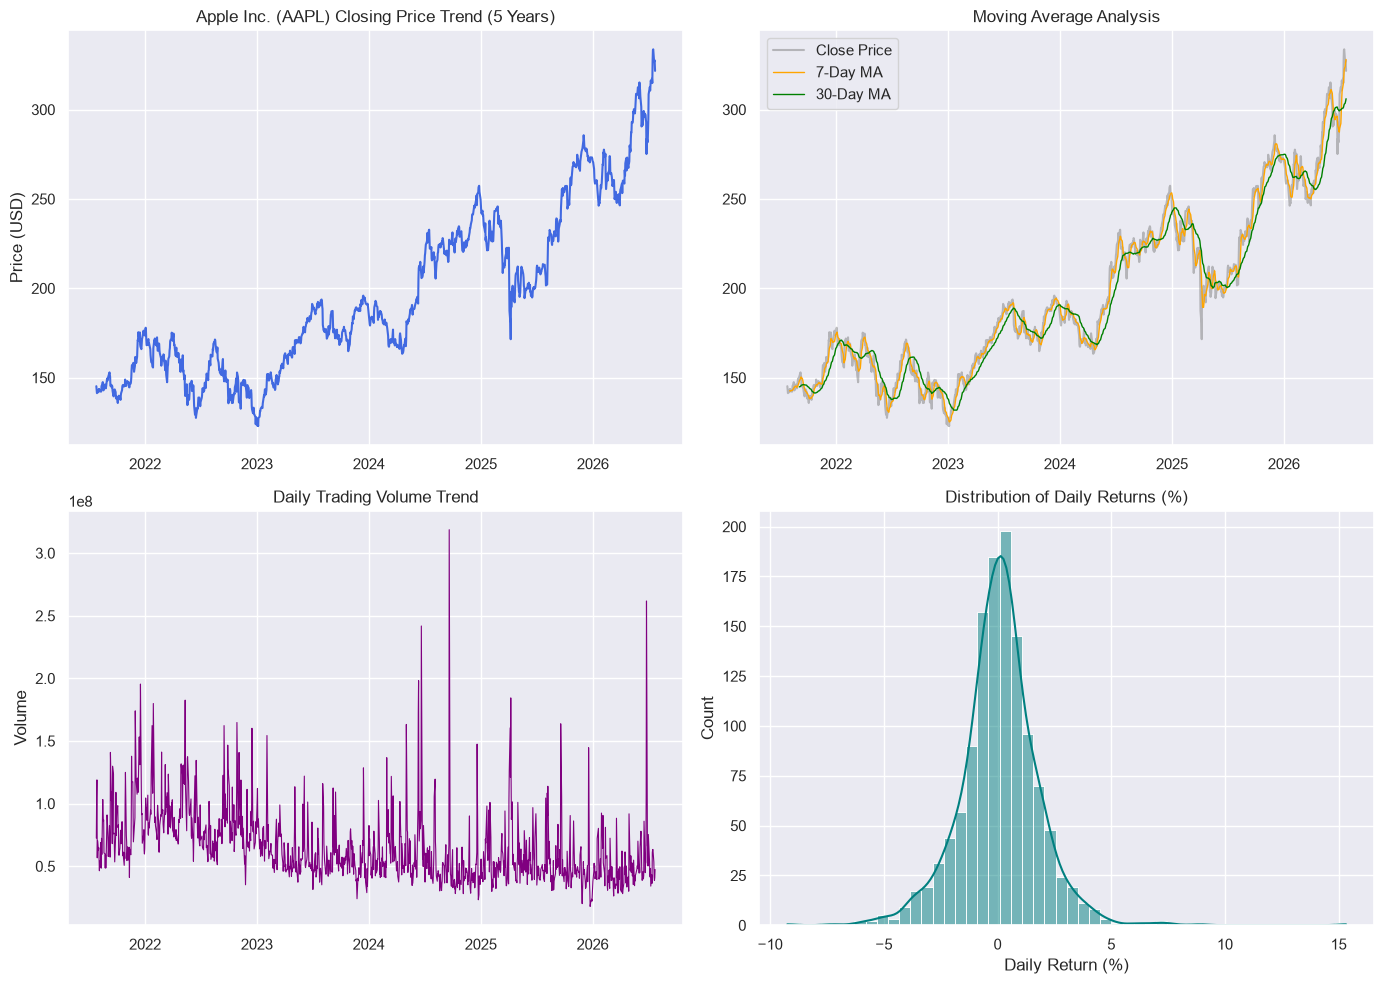

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# 1. Stock Closing Price Trend
axes[0, 0].plot(df['Date'], df['Close'], color='royalblue', linewidth=1.5)
axes[0, 0].set_title('Apple Inc. (AAPL) Closing Price Trend (5 Years)')
axes[0, 0].set_ylabel('Price (USD)')

# 2. Moving Average Analysis (Close vs MA_7 vs MA_30)
axes[0, 1].plot(df['Date'], df['Close'], label='Close Price', color='gray', alpha=0.5)
axes[0, 1].plot(df['Date'], df['MA_7'], label='7-Day MA', color='orange', linewidth=1)
axes[0, 1].plot(df['Date'], df['MA_30'], label='30-Day MA', color='green', linewidth=1)
axes[0, 1].set_title('Moving Average Analysis')
axes[0, 1].legend(loc='upper left')

# 3. Trading Volume Trend
axes[1, 0].plot(df['Date'], df['Volume'], color='purple', linewidth=0.8)
axes[1, 0].set_title('Daily Trading Volume Trend')
axes[1, 0].set_ylabel('Volume')

# 4. Daily Returns Distribution
sns.histplot(df['Daily_Return'].dropna(), bins=50, ax=axes[1, 1], color='teal', kde=True)
axes[1, 1].set_title('Distribution of Daily Returns (%)')
axes[1, 1].set_xlabel('Daily Return (%)')

plt.tight_layout()
plt.show()